In [35]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv(r"C:\Users\Sonali Nayak\Downloads\Task-7-Sales-Summary-SQLite\Online Sales Data.csv")

In [37]:
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [38]:
sales_df = df[["Product Name", "Units Sold", "Total Revenue"]]

In [39]:
sales_df.columns = ["product", "quantity", "revenue"]

In [40]:
sales_df.head()

,product,quantity,revenue
0,iPhone 14 Pro,2,1999.98
1,Dyson V11 Vacuum,1,499.99
2,Levi's 501 Jeans,3,209.97
3,The Da Vinci Code,4,63.96
4,Neutrogena Skincare Set,1,89.99


In [41]:
conn = sqlite3.connect("sales_data.db")

In [42]:
sales_df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

240

In [43]:
query = "SELECT product, SUM(quantity) AS total_quantity, SUM(revenue) AS total_revenue FROM sales GROUP BY product;"

In [44]:
result = pd.read_sql_query(query, conn)

In [45]:
print(result)

                                               product  total_quantity  \
0                                1984 by George Orwell               4   
1                              Adidas 3-Stripes Shorts               5   
2                         Adidas Essential Track Pants               3   
3                       Adidas FIFA World Cup Football               3   
4                  Adidas Originals Superstar Sneakers               4   
..                                                 ...             ...   
227           Yeti Tundra Haul Portable Wheeled Cooler               1   
228  Youth to the People Superfood Antioxidant Clea...               1   
229                                  Zara Summer Dress               3   
230                                      iPhone 14 Pro               2   
231                               iRobot Braava Jet M6               1   

     total_revenue  
0            79.96  
1           149.95  
2           134.97  
3            89.97  
4     

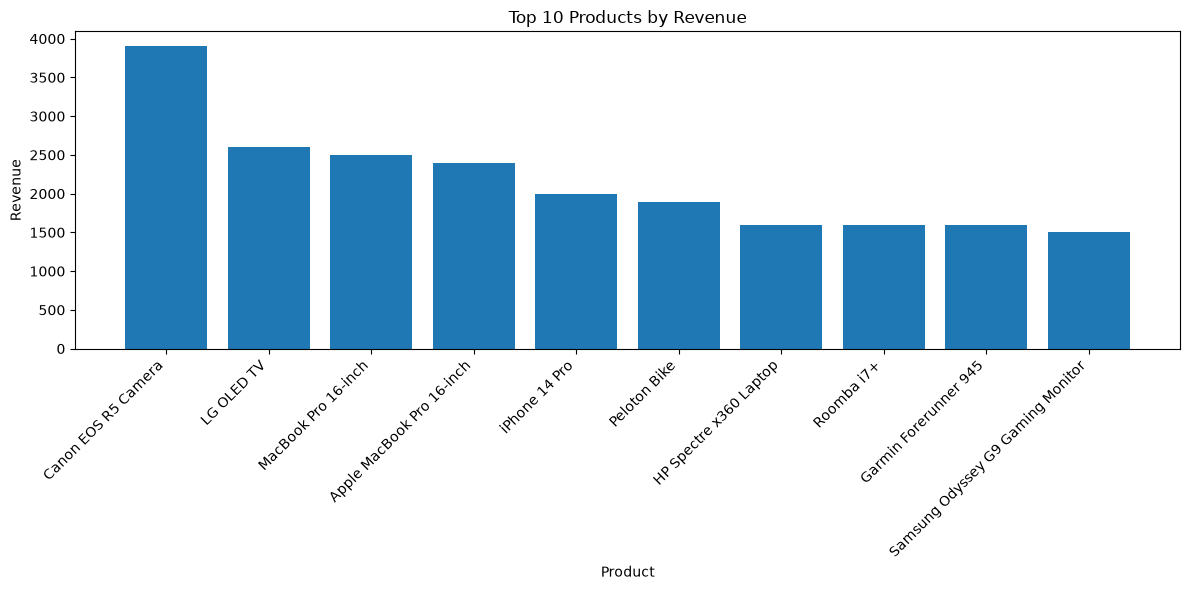

In [52]:
# Sort by revenue and select the top 10 products
top10 = result.sort_values(by="total_revenue", ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(top10["product"], top10["total_revenue"])

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("sales_chart1.png")

plt.show()

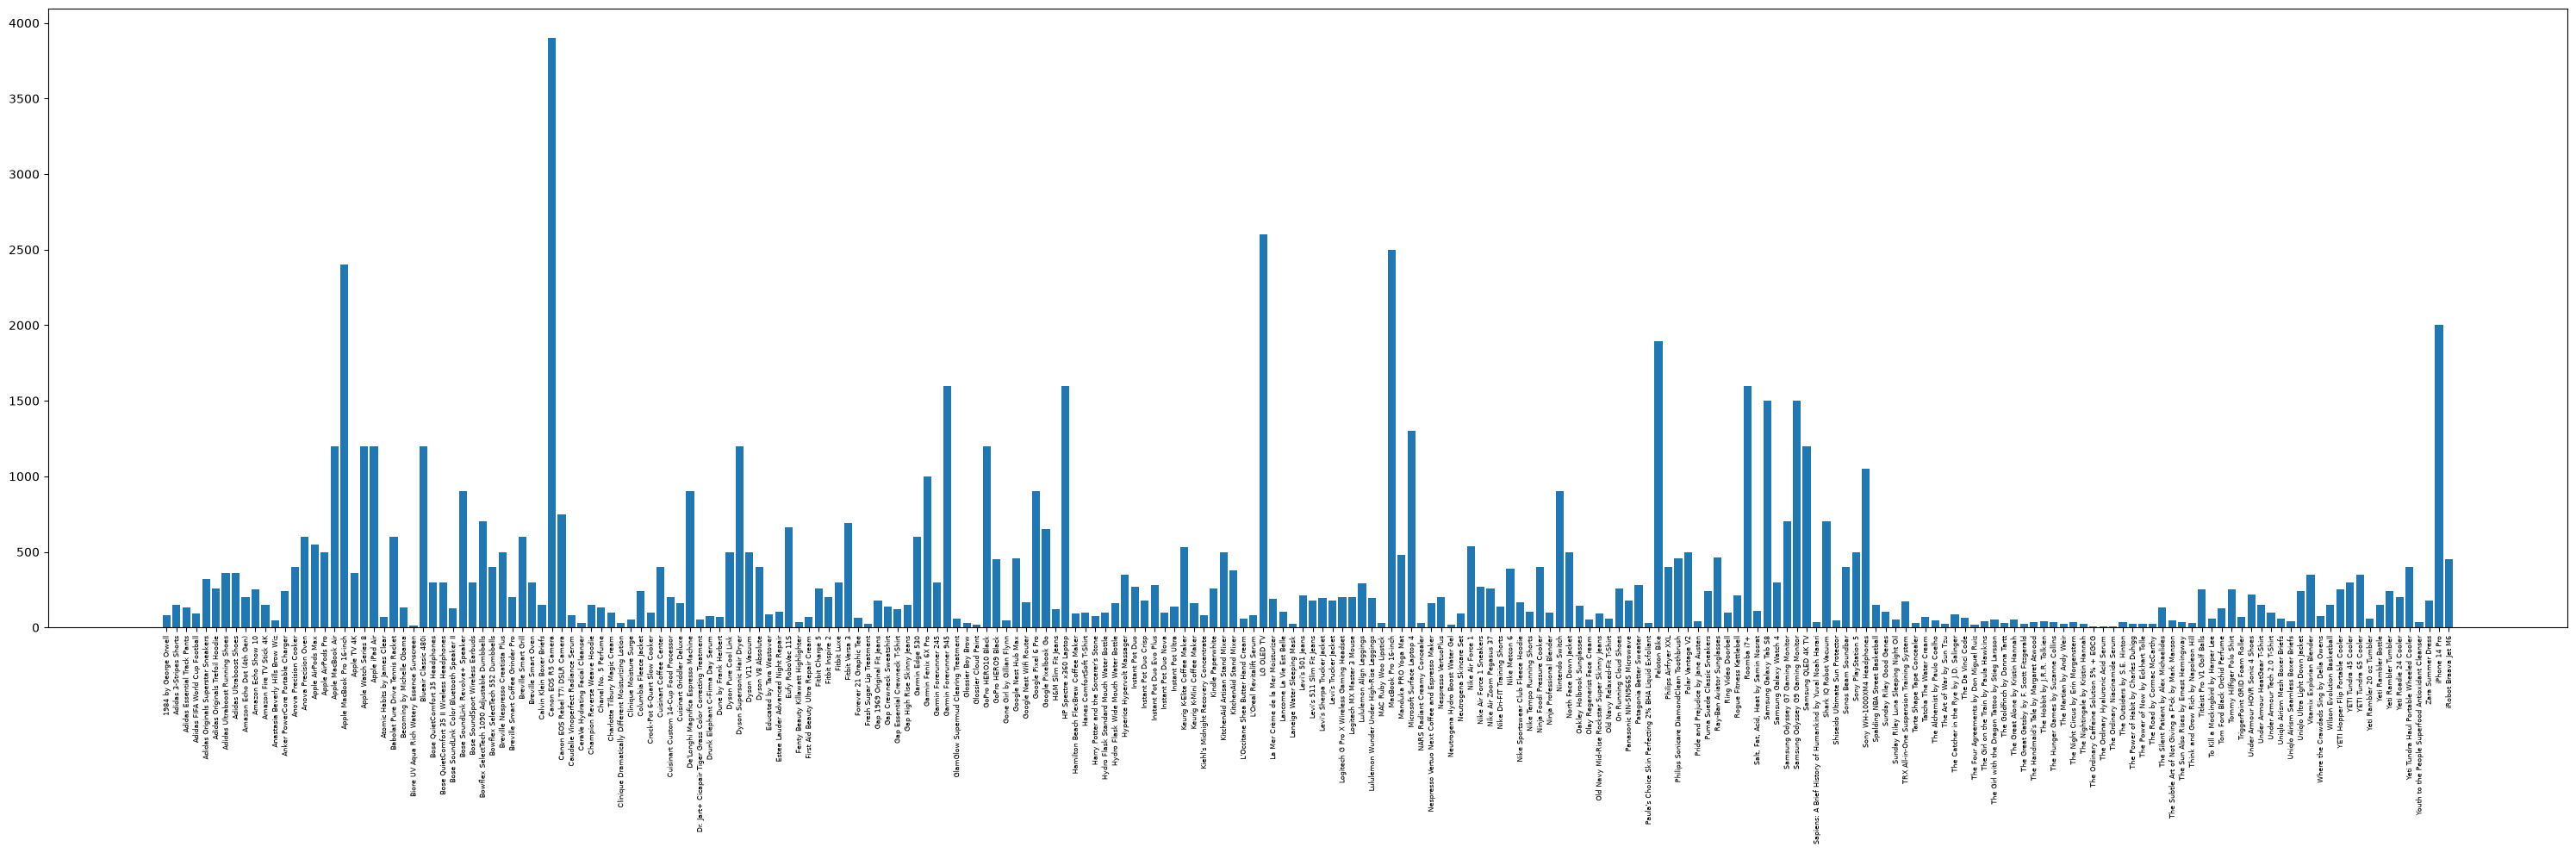

In [53]:
plt.figure(figsize=(30,10))
plt.bar(result["product"], result["total_revenue"])
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("sales_chart2.png")
plt.show()

In [54]:
plt.savefig("sales_chart.png")
plt.show()

<Figure size 640x480 with 0 Axes>

In [56]:
conn.close()